# ESM features + CNN features → Hybrid classifier → compare with separate models

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [2]:
df = pd.read_csv("../dataset/protein_balanced.csv")

df_hybrid = df.groupby("label").sample(n=5000, random_state=42)

df_hybrid["label"].value_counts()

label
binding      5000
enzyme       5000
transport    5000
Name: count, dtype: int64

In [3]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}

MAX_LEN = 300

def encode_sequence(seq):
    seq = seq.upper()
    encoded = [aa_to_int.get(aa, 0) for aa in seq[:MAX_LEN]]
    encoded += [0] * (MAX_LEN - len(encoded))
    return encoded[:MAX_LEN]

In [4]:
X_cnn = np.array([encode_sequence(seq) for seq in df_hybrid["sequence"]])

label_encoder = LabelEncoder()
y_labels = label_encoder.fit_transform(df_hybrid["label"])

print(X_cnn.shape)
print(y_labels.shape)
print(label_encoder.classes_)

(15000, 300)
(15000,)
['binding' 'enzyme' 'transport']


In [5]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, vocab_size=21, embed_dim=128, num_classes=3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)

        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x, return_features=False):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))

        x = self.pool(x).squeeze(-1)

        features = torch.relu(self.fc1(x))
        output = self.fc2(self.dropout(features))

        if return_features:
            return features

        return output

In [6]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_cnn, dtype=torch.long)
y_tensor = torch.tensor(y_labels, dtype=torch.long)

all_dataset = TensorDataset(X_tensor, y_tensor)
all_loader = DataLoader(all_dataset, batch_size=64, shuffle=False)

In [7]:
model_cnn = CNNFeatureExtractor().to(device)

In [8]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

class ProteinDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ProteinDataset(X_train_cnn, y_train_cnn)
test_dataset = ProteinDataset(X_test_cnn, y_test_cnn)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = CNNFeatureExtractor().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 15

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/15], Loss: 0.7671
Epoch [2/15], Loss: 0.5254
Epoch [3/15], Loss: 0.3975
Epoch [4/15], Loss: 0.2846
Epoch [5/15], Loss: 0.2120
Epoch [6/15], Loss: 0.1512
Epoch [7/15], Loss: 0.1040
Epoch [8/15], Loss: 0.0704
Epoch [9/15], Loss: 0.0451
Epoch [10/15], Loss: 0.0275
Epoch [11/15], Loss: 0.0176
Epoch [12/15], Loss: 0.0151
Epoch [13/15], Loss: 0.0117
Epoch [14/15], Loss: 0.0139
Epoch [15/15], Loss: 0.0297


In [10]:
model_cnn.eval()

cnn_features = []

with torch.no_grad():
    for batch_X, batch_y in all_loader:

        batch_X = batch_X.to(device)

        features = model_cnn(batch_X, return_features=True)

        cnn_features.append(features.cpu().numpy())

cnn_features = np.vstack(cnn_features)

print(cnn_features.shape)

(15000, 128)


In [11]:
import numpy as np

X_embeddings = np.load("../models/X_embeddings.npy")
y_labels = np.load("../models/y_labels.npy")

print(X_embeddings.shape)
print(y_labels.shape)

(15000, 320)
(15000,)


In [12]:
print(cnn_features.shape)
print(X_embeddings.shape)

(15000, 128)
(15000, 320)


In [13]:
hybrid_features = np.concatenate(
    [X_embeddings, cnn_features],
    axis=1
)

print(hybrid_features.shape)

(15000, 448)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    hybrid_features,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

hybrid_model = SVC(kernel="linear")

hybrid_model.fit(X_train, y_train)

y_pred = hybrid_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Hybrid Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Hybrid Accuracy: 0.902
              precision    recall  f1-score   support

     binding       0.89      0.90      0.90      1000
      enzyme       0.89      0.89      0.89      1000
   transport       0.92      0.92      0.92      1000

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



In [15]:
import joblib

joblib.dump(
    hybrid_model,
    "../models/hybrid_cnn_esm_model.pkl"
)

print("Hybrid model saved successfully!")

Hybrid model saved successfully!


In [16]:
import numpy as np

np.save("../models/hybrid_features.npy", hybrid_features)

print("Hybrid features saved!")

Hybrid features saved!


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

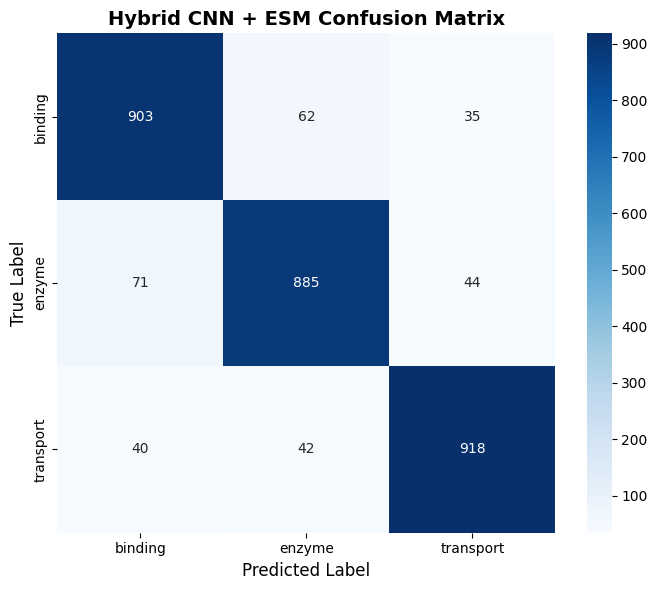

In [18]:
plot_conf_matrix(
    y_test,
    y_pred,
    "Hybrid CNN + ESM Confusion Matrix",
    ["binding", "enzyme", "transport"]
)